# Animation

So far we focused on static images, but matplotlib does have some support for animation. This requires a separate library to use in the Jupyter notebook called `ipympl`, and I've installed that for you here. Animation depends on this library because it provides a new backend for us, call the `widget` backend. Let's turn that on here.

In [2]:
%matplotlib inline


# We can bring in some other libraries we will need too, including the
# matplotlib animation module
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from matplotlib import rcParams
# matplotlib.use('TkAgg')   # Most common working backend
rcParams["animation.html"] = "jshtml"


The Maplotlib.animation module contains important helpers for building animations, and for our discussion today the important object we are going to use is called `FuncAnimation`. This builds an animation by iteratively calling a function which you define. This function's job is to clear the axis object and redraw the next frame of the animation. Then these frames are all stacked together into a playable video.

I like to use this demonstration in my classes here at Michigan to show students how distributions can be sampled from. So we're going to build a basic animation which is going to pull 100 samples out of the normal distribution. Let's generate that data now.

In [2]:
n = 100
x = np.random.randn(n)

NameError: name 'np' is not defined

Okay, next we want to actually create a function which will do the plotting. We'll call this function `update`. Now the matplotlib FuncAnimation object is going to call this every few milliseconds and pass in the frame number we are on starting with frame zero. So we can use this is as the index into our array values, which we called `x`.

The very first thing we want to do is see if the current frame is at the end of our list. If so, we need to tell the animation to stop. We do this by calling the stop object on the event source object attached to the FuncAnimation object.

In [4]:
# create the function that will do the plotting, where curr is the current frame
def update(curr):
    # check if animation is at the last frame, and if so, stop the animation a
    if curr == n: 
        a.event_source.stop()

    # What is a? Well, it's an object that we'll define in a bit, and it will
    # sit outside of this function but we can still access it since python allows
    # us to access variables in the global scope.

    # Now on to the work. First thing we want to do is clear the current axes.
    # We can do this with plt.cla().
    plt.cla()

    # Now I jut want to plot a histogram. I'm going to set my bins to a predictable
    # value so it doesn't jump around, but you can play with this
    bins = np.arange(-4, 4, 0.5)

    # Then we just make the hist() using the current frame number which was passed
    # into the function and our global values array
    plt.hist(x[:curr], bins=bins)

    # Set the axes limits
    plt.axis([-4,4,0,30])

    # And add some nice labels throughout
    plt.gca().set_title('Sampling the Normal Distribution')
    plt.gca().set_ylabel('Frequency')
    plt.gca().set_xlabel('Value')
    plt.annotate('n = {}'.format(curr), [3,27])

Now most of our hard work is done so we just have to view it. To do this, we just generate a new figure, then call the FuncAnimation constructor and we'll assign this to variable a, since we need this for our `update()` function which will stop the animation at the end. The first parameter is the figure that we're working with. This isn't so important here, since we're using the pylot scripting interface to manage the figure. Then the name of our function and then the amount of time we want between updates. Let's set this to 100 milliseconds.

In [1]:
# Quick to start

#  FIXED VERSION: Explicit frames and save_count
frames = range(5, n + 1, 5)  # Start at 5, increment by 5
a = animation.FuncAnimation(plt.figure(), update, frames=frames,  interval=100, save_count=len(frames),  # Fix the warning
    cache_frame_data=False,  # Disable caching to avoid warning
    repeat=False )

# Now tell the widget back end it's time to show!
plt.tight_layout()
plt.show()

NameError: name 'n' is not defined

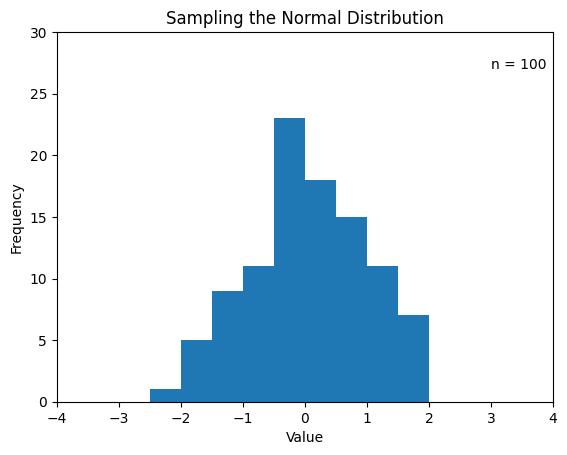

In [41]:
a.save('test.gif', writer='pillow', fps=10)

There we go. A nice example of how sampling from a distribution an be used with an animation.

FuncAnimation like most of the other classes in the animation package is a subclass of the animation object. The animation object has a handy safe function, which allows you to write the animation to a file. This requires additional third party library such as FFMpeg which can take a bit to install and set up. But the result is that you can fairly easily export your animations directly from the Jupiter Web programming environment. 

You know, a figure animation with four sub-plots, one for each kind of distribution we might be interested in understanding could be pretty neat to see. We could plot the samples for the normal distribution in one, for a gamma distribution in another, and then maybe a couple of paramaterized distributions like the normal distribution with different levels of standard deviation. This would be a great way to practice the skills that you've learned in this module, as it would require that you manage multiple sub-plots within an animation using histograms. If you want to tackle that challenge, I'll put a link in the course shell to an optional practice notebook for you to look at.